In [1]:
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [2]:
df = pd.read_csv("Downloads/monster_no_skills.csv")
df= df.drop_duplicates() 
columns_to_drop= ['_id', 'url', 'crawled_at', 'expires_at', 'postal_code', 'street_address','address_region','address_locality','address_country','months_of_experience']
df=df.drop(columns=columns_to_drop)
print(df.info())
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')

# Save the modified DataFrame to a new CSV file
df.to_csv("Downloads/monster_no_skills_cleaned.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14146 entries, 0 to 14145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   title                  14146 non-null  object
 1   description            14146 non-null  object
 2   posted_at              14146 non-null  object
 3   job_type               14146 non-null  object
 4   company_name           14139 non-null  object
 5   qualifications         1274 non-null   object
 6   responsibilities       12591 non-null  object
 7   industry               13830 non-null  object
 8   occupational_category  14129 non-null  object
 9   skills                 9073 non-null   object
 10  salary                 14139 non-null  object
 11  currency               14139 non-null  object
 12  experience             14139 non-null  object
dtypes: object(13)
memory usage: 1.5+ MB
None


In [3]:
# Aggregate job postings per month
monster_recent = pd.read_csv("Downloads/monster_no_skills_cleaned.csv")
monster_recent['posted_at'] = pd.to_datetime(monster_recent['posted_at'])
monster_recent['year_month'] = monster_recent['posted_at'].dt.to_period('M') 
job_trends = monster_recent.groupby('year_month').size().reset_index(name='job_postings')

In [4]:
job_trends['ds'] = job_trends['year_month'].astype(str)
job_trends['ds'] = pd.to_datetime(job_trends['ds'])
job_trends = job_trends[['ds', 'job_postings']]

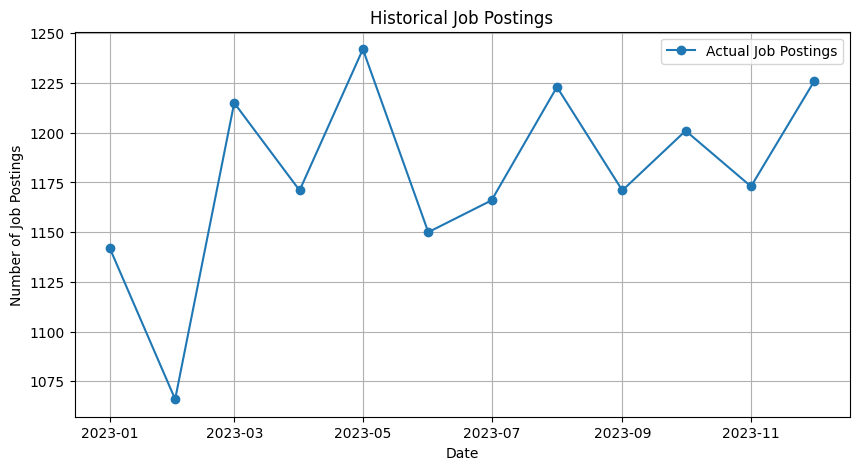

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(job_trends['ds'], job_trends['job_postings'], marker='o', label='Actual Job Postings')
plt.title("Historical Job Postings")
plt.xlabel("Date")
plt.ylabel("Number of Job Postings")
plt.grid()
plt.legend()
plt.show()

C:\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


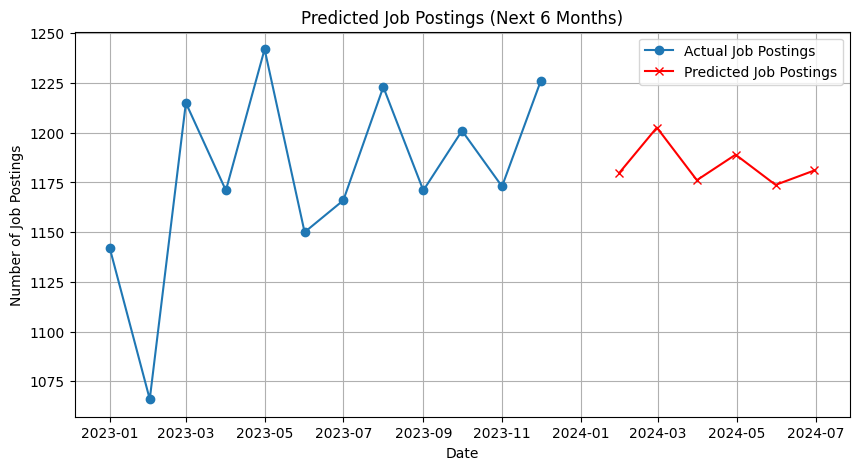

In [8]:
model = ARIMA(job_trends['job_postings'], order=(2, 1, 2))  
model_fit = model.fit() 

# Forecast the next 6 months
forecast = model_fit.forecast(steps=6)

future_dates = pd.date_range(start=job_trends['ds'].max(), periods=7, freq='M')[1:]
forecast_df = pd.DataFrame({'ds': future_dates, 'job_postings': forecast})

# Plot the forecast
plt.figure(figsize=(10, 5))
plt.plot(job_trends['ds'], job_trends['job_postings'], marker='o', label='Actual Job Postings')
plt.plot(forecast_df['ds'], forecast_df['job_postings'], marker='x', color='red', label='Predicted Job Postings')
plt.title("Predicted Job Postings (Next 6 Months)")
plt.xlabel("Date")
plt.ylabel("Number of Job Postings")
plt.grid()
plt.legend()
plt.show()

In [9]:
forecast_df.to_csv("Downloads/arima_job_postings.csv", index=False)

In [12]:
df = pd.read_csv("Downloads/monster_no_skills_cleaned.csv")
df['posted_at'] = pd.to_datetime(df['posted_at'])
daily_counts = df.groupby('posted_at').size().sort_index()

In [13]:
train_size = int(len(daily_counts) * 0.75)
train, test = daily_counts[:train_size], daily_counts[train_size:]
model = ARIMA(train, order=(2, 1, 2)) 
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))


C:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-in

In [14]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(test, forecast)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 31.03


C:\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: 

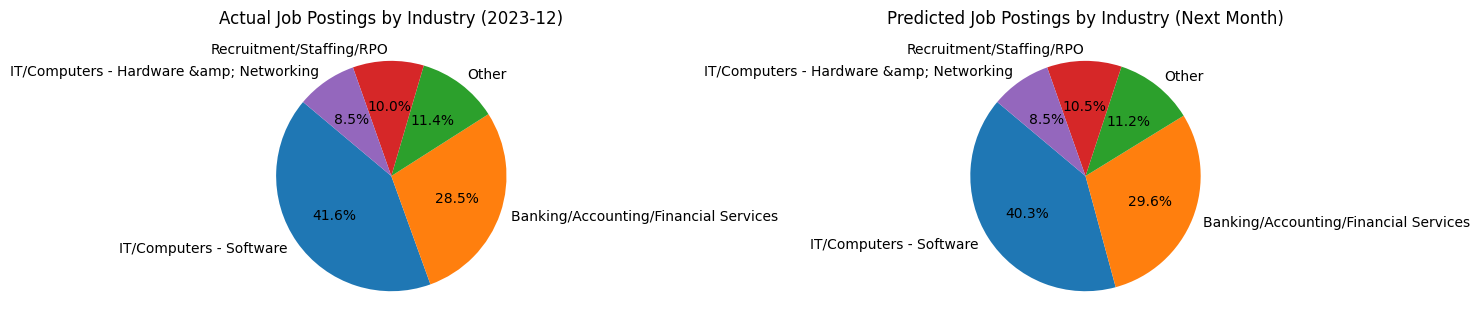

In [12]:
df = pd.read_csv("Downloads/monster_no_skills_cleaned.csv")

# Convert 'posted_at' to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')

# Drop rows with missing 'posted_at' or 'industry'
df = df.dropna(subset=['posted_at', 'industry'])

# Extract month from 'posted_at'
df['month'] = df['posted_at'].dt.to_period('M')

# Group by month and industry to count job postings
industry_monthly_counts = df.groupby(['month', 'industry']).size().unstack(fill_value=0)

# Get top 5 industries by total postings
top_industries = industry_monthly_counts.sum().sort_values(ascending=False).head(5).index
top_industry_data = industry_monthly_counts[top_industries]

# Forecast next month using ARIMA for each industry
forecast_results = {}
for industry in top_industries:
    series = top_industry_data[industry].astype(float)
    try:
        model = ARIMA(series, order=(2, 1, 2))
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=1)
        forecast_results[industry] = forecast.iloc[0]
    except:
        forecast_results[industry] = np.nan

# Get actual counts from the most recent month
latest_month = top_industry_data.index.max()
actual_counts = top_industry_data.loc[latest_month]

# Prepare predicted counts as a Series
predicted_counts = pd.Series(forecast_results).fillna(0)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual data pie chart
axes[0].pie(actual_counts, labels=actual_counts.index, autopct='%1.1f%%', startangle=140)
axes[0].set_title(f"Actual Job Postings by Industry ({latest_month})")

# Predicted data pie chart
axes[1].pie(predicted_counts, labels=predicted_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title("Predicted Job Postings by Industry (Next Month)")

plt.tight_layout()
plt.show()